<a href="https://colab.research.google.com/github/mfragiadakis/mfragiadakis/blob/main/stft_welch_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time-Frequency Analysis: STFT & Welch Spectra

Companion notebook to the lecture slides `sgnl_08_TF_analysis.pptx`
("Time-Frequency Analysis & Short Time Fourier Transform").

The notebook walks through:
1. Why the plain FFT cannot tell **when** frequencies occur.
2. The **Short-Time Fourier Transform (STFT)** and how each parameter (window length, overlap, FFT length, window shape) reshapes the spectrogram — including the Heisenberg time / frequency trade-off.
3. **Welch's method** for power spectral density estimation and how its parameters (segment length, overlap, window, scaling, averaging) trade variance for resolution.

All examples use the same test signal: four sinusoids (10, 25, 50, 100 Hz) joined back-to-back, sampled at 400 Hz — the signal from slide 60.

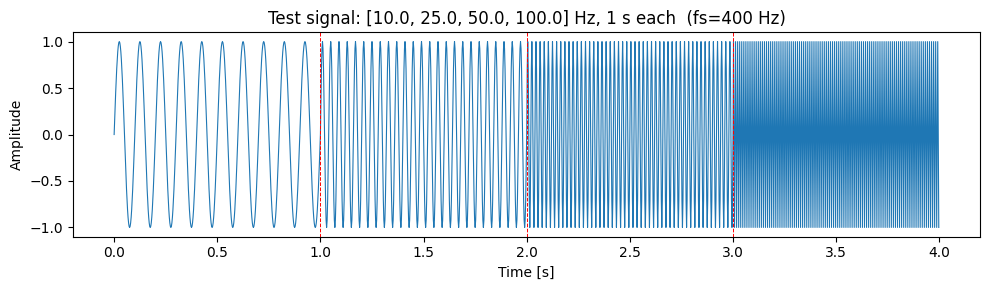

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

rng = np.random.default_rng(0)

# ---- Test signal: 4 sinusoids switching every 1 s ----
fs = 400.0           # sampling frequency [Hz]
duration = 4.0       # total length [s]
t = np.arange(0, duration, 1/fs)
N = t.size

seg_freqs = [10.0, 25.0, 50.0, 100.0]   # Hz, one per second
seg_len = N // 4
x = np.concatenate([
    np.sin(2*np.pi*f*t[i*seg_len:(i+1)*seg_len])
    for i, f in enumerate(seg_freqs)
])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, x, lw=0.8)
for k in range(1, 4):
    ax.axvline(k, color='r', ls='--', lw=0.7)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude')
ax.set_title(f'Test signal: {seg_freqs} Hz, 1 s each  (fs={fs:.0f} Hz)')
fig.tight_layout()
plt.show()

## 1. Why the plain FFT fails on non-stationary signals

The FFT integrates over **all** time, so peaks appear at every frequency that is ever present, but the time information is gone — the limitation discussed in slides 8–17.

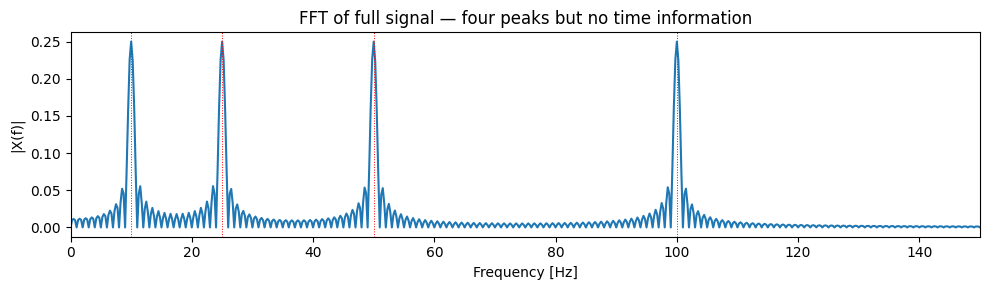

In [2]:
X = np.fft.rfft(x)
freqs_fft = np.fft.rfftfreq(N, 1/fs)
mag = 2.0 * np.abs(X) / N

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(freqs_fft, mag)
for f0 in seg_freqs:
    ax.axvline(f0, color='r', ls=':', lw=0.7)
ax.set_xlim(0, 150)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('|X(f)|')
ax.set_title('FFT of full signal — four peaks but no time information')
fig.tight_layout()
plt.show()

## 2. Short-Time Fourier Transform (STFT)

The STFT slides a window along the signal and takes the FFT of each windowed segment, producing a 2-D spectrogram of frequency vs time (slides 18–41).

`scipy.signal.stft` exposes four knobs that control the result:

| Parameter | Meaning | Effect |
|-----------|---------|--------|
| `nperseg` | window length (samples) | sets the **time / frequency trade-off**: Δt = nperseg/fs, Δf = fs/nperseg |
| `noverlap` | samples shared between adjacent windows | more overlap → smoother spectrogram, more compute |
| `nfft` | FFT length per window (zero-pads if > `nperseg`) | finer **display** resolution; does not improve true Δf |
| `window` | tapering shape (`'hann'`, `'hamming'`, `'blackman'`, `'boxcar'`, …) | controls spectral leakage / side-lobe level |

The cell below is the single, fully-labelled STFT call you can modify.

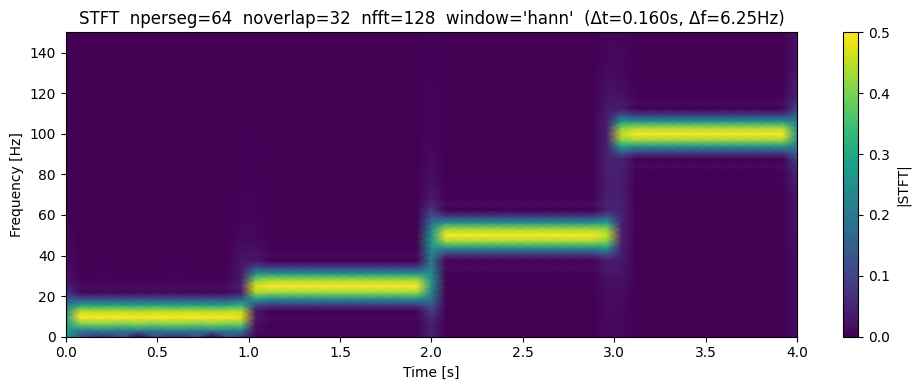

In [3]:
# ---- knobs you can change ----
nperseg  = 64           # window length [samples]
noverlap = 32           # 50 % overlap
nfft     = 128          # zero-pad each window to nfft samples
window   = 'hann'       # taper shape
# -------------------------------

f_stft, t_stft, Zxx = signal.stft(
    x, fs=fs, window=window,
    nperseg=nperseg, noverlap=noverlap, nfft=nfft,
)

fig, ax = plt.subplots(figsize=(10, 4))
pcm = ax.pcolormesh(t_stft, f_stft, np.abs(Zxx),
                    shading='gouraud', cmap='viridis')
ax.set_ylim(0, 150)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Frequency [Hz]')
ax.set_title(
    f"STFT  nperseg={nperseg}  noverlap={noverlap}  "
    f"nfft={nfft}  window='{window}'  "
    f"(Δt={nperseg/fs:.3f}s, Δf={fs/nperseg:.2f}Hz)"
)
fig.colorbar(pcm, ax=ax, label='|STFT|')
fig.tight_layout()
plt.show()

### 2.1 Window length — the Heisenberg trade-off

Narrow window → sharp in time but coarse in frequency.
Wide window → fine in frequency but blurry in time (slides 56–59).

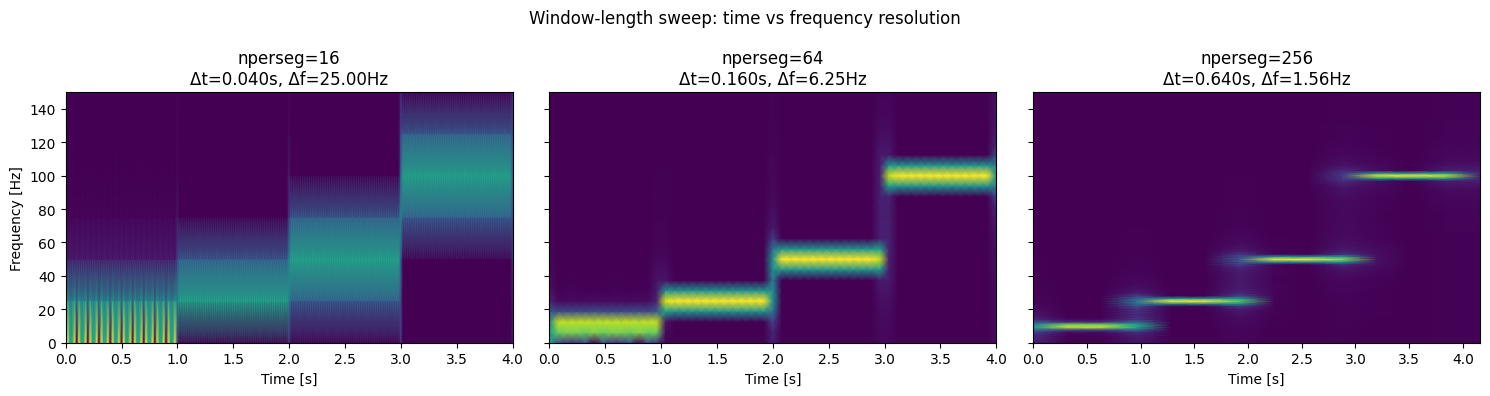

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, nps in zip(axes, [16, 64, 256]):
    f_s, t_s, Z = signal.stft(x, fs=fs, nperseg=nps,
                              noverlap=nps//2, window='hann')
    ax.pcolormesh(t_s, f_s, np.abs(Z), shading='gouraud', cmap='viridis')
    ax.set_ylim(0, 150)
    ax.set_xlabel('Time [s]')
    ax.set_title(f'nperseg={nps}\nΔt={nps/fs:.3f}s, Δf={fs/nps:.2f}Hz')
axes[0].set_ylabel('Frequency [Hz]')
fig.suptitle('Window-length sweep: time vs frequency resolution')
fig.tight_layout()
plt.show()

### 2.2 Window shape and overlap

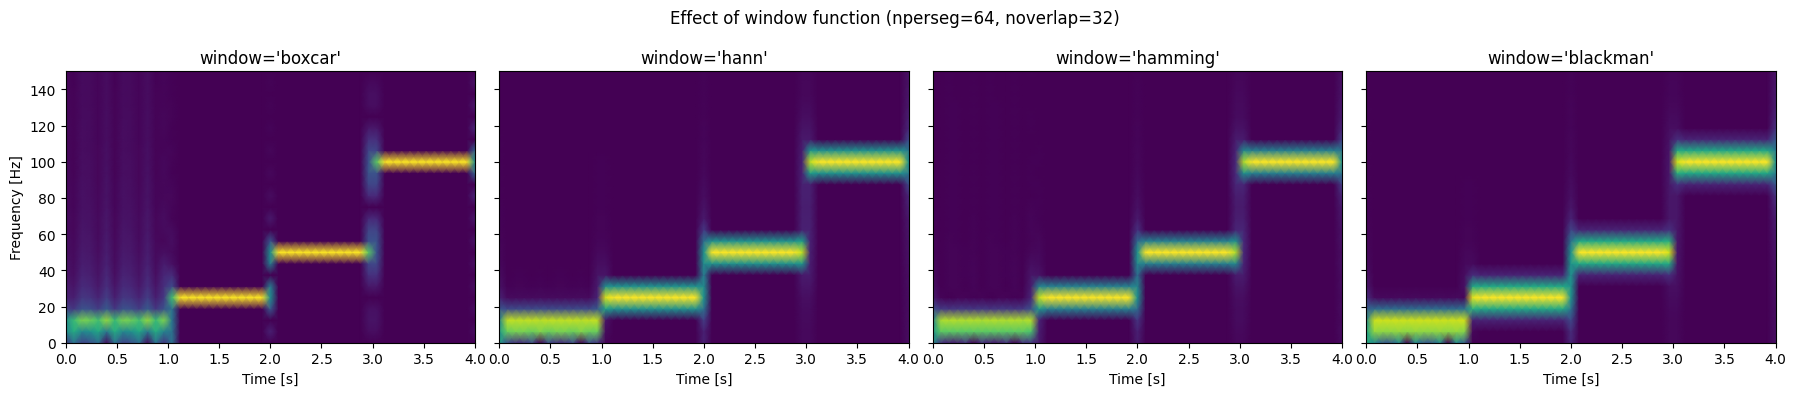

In [5]:
# Window-function sweep — same nperseg, different taper shapes.
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, win in zip(axes, ['boxcar', 'hann', 'hamming', 'blackman']):
    f_s, t_s, Z = signal.stft(x, fs=fs, window=win,
                              nperseg=64, noverlap=32)
    ax.pcolormesh(t_s, f_s, np.abs(Z), shading='gouraud', cmap='viridis')
    ax.set_ylim(0, 150)
    ax.set_xlabel('Time [s]')
    ax.set_title(f"window='{win}'")
axes[0].set_ylabel('Frequency [Hz]')
fig.suptitle('Effect of window function (nperseg=64, noverlap=32)')
fig.tight_layout()
plt.show()

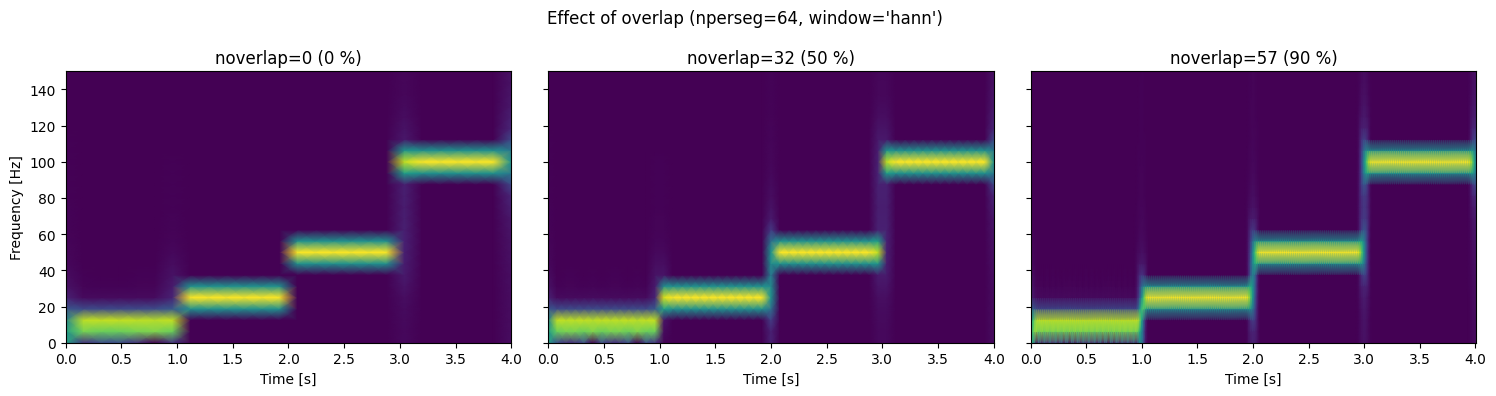

In [6]:
# Overlap sweep — more overlap smooths the spectrogram in time.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
nps = 64
for ax, ov_frac in zip(axes, [0.0, 0.5, 0.9]):
    nov = int(ov_frac * nps)
    f_s, t_s, Z = signal.stft(x, fs=fs, nperseg=nps,
                              noverlap=nov, window='hann')
    ax.pcolormesh(t_s, f_s, np.abs(Z), shading='gouraud', cmap='viridis')
    ax.set_ylim(0, 150)
    ax.set_xlabel('Time [s]')
    ax.set_title(f'noverlap={nov} ({int(ov_frac*100)} %)')
axes[0].set_ylabel('Frequency [Hz]')
fig.suptitle("Effect of overlap (nperseg=64, window='hann')")
fig.tight_layout()
plt.show()

## 3. Welch's method — averaged power spectral density

Welch's method extends what the STFT computes: it splits the signal into overlapping segments, takes the periodogram of each, and **averages** them. The output is a single PSD curve — the time dimension is collapsed — but the averaging dramatically reduces the variance of the estimate compared with a single periodogram.

`scipy.signal.welch` exposes:

| Parameter | Meaning | Effect |
|-----------|---------|--------|
| `nperseg` | segment length | larger → finer Δf but **fewer segments → noisier estimate** |
| `noverlap` | samples shared between segments (default 50 %) | trades compute for variance reduction |
| `window` | taper shape per segment | spectral leakage control |
| `nfft` | FFT length per segment (zero-pad) | display resolution only |
| `detrend` | `'constant'`, `'linear'`, or `False` | removes mean/trend from each segment |
| `scaling` | `'density'` (V²/Hz) or `'spectrum'` (V²) | physical units of the output |
| `average` | `'mean'` or `'median'` | median is robust against transients |

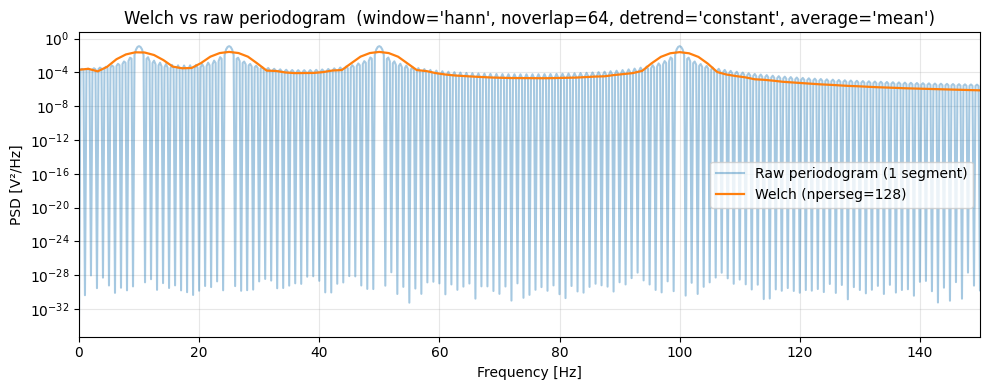

In [7]:
# ---- knobs you can change ----
nperseg  = 128
noverlap = 64
window   = 'hann'
nfft     = 256
detrend  = 'constant'
scaling  = 'density'      # 'density' (V^2/Hz) or 'spectrum' (V^2)
average  = 'mean'         # 'mean' or 'median'
# -------------------------------

f_w, Pxx = signal.welch(
    x, fs=fs, window=window,
    nperseg=nperseg, noverlap=noverlap, nfft=nfft,
    detrend=detrend, scaling=scaling, average=average,
)

# Compare against a raw periodogram (no segment averaging).
f_p, Pp = signal.periodogram(x, fs=fs, window='boxcar', scaling=scaling)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(f_p, Pp, alpha=0.4, label='Raw periodogram (1 segment)')
ax.semilogy(f_w, Pxx, lw=1.6, label=f'Welch (nperseg={nperseg})')
ax.set_xlim(0, 150)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('PSD [V²/Hz]' if scaling == 'density' else 'Power [V²]')
ax.set_title(
    f"Welch vs raw periodogram  (window='{window}', noverlap={noverlap}, "
    f"detrend='{detrend}', average='{average}')"
)
ax.grid(True, which='both', alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

### 3.1 Segment-length sweep — bias / variance trade-off

Short segments give many averages (smooth PSD) but coarse Δf; long segments give sharper peaks but fewer averages (noisier curve).

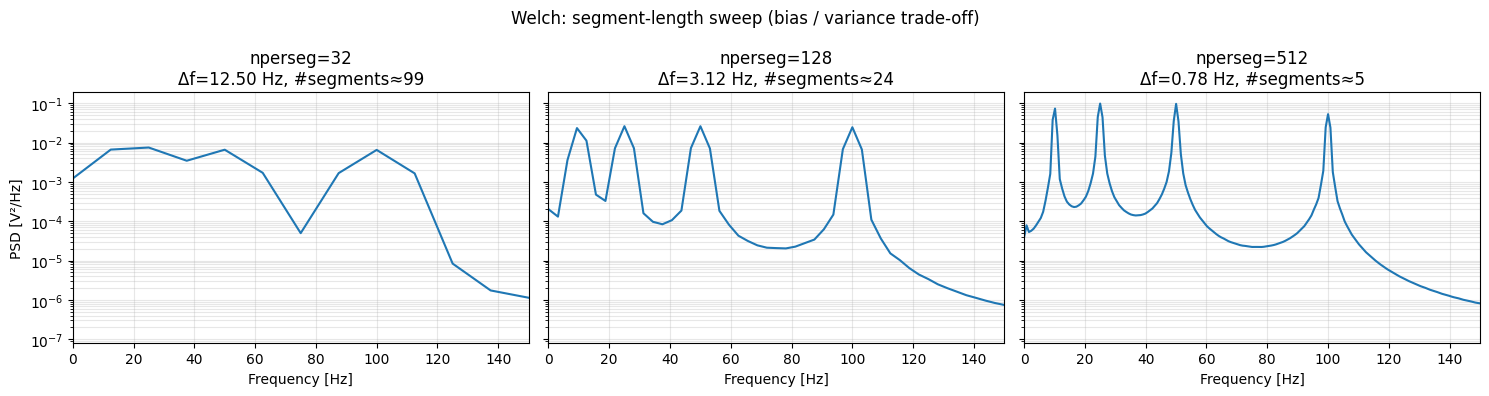

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, nps in zip(axes, [32, 128, 512]):
    f_w, Pxx = signal.welch(x, fs=fs, nperseg=nps,
                            noverlap=nps//2, window='hann')
    n_segments = max(1, (N - nps) // (nps//2) + 1)
    ax.semilogy(f_w, Pxx)
    ax.set_xlim(0, 150)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_title(f'nperseg={nps}\nΔf={fs/nps:.2f} Hz, #segments≈{n_segments}')
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('PSD [V²/Hz]')
fig.suptitle('Welch: segment-length sweep (bias / variance trade-off)')
fig.tight_layout()
plt.show()

### 3.2 `average='mean'` vs `'median'`

Add a short noise burst to the signal and compare. Median averaging is robust against transient segments that would inflate the mean-averaged PSD.

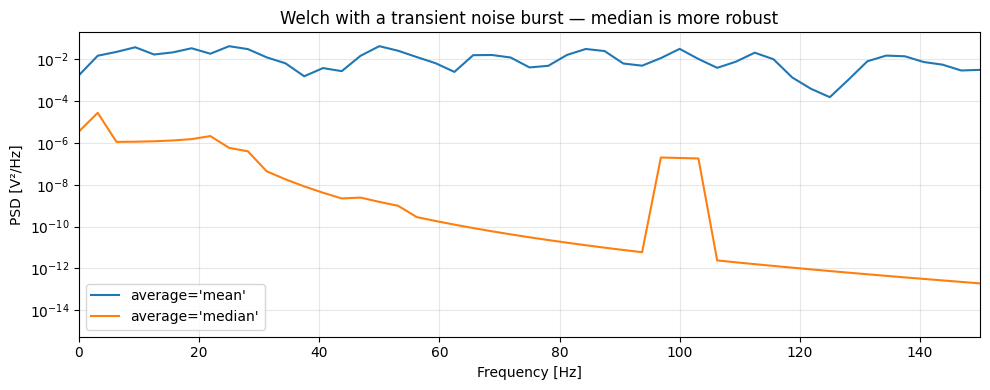

In [9]:
x_burst = x.copy()
burst = slice(800, 900)              # 0.25 s burst inside the 50 Hz segment
x_burst[burst] += 6.0 * rng.standard_normal(burst.stop - burst.start)

fig, ax = plt.subplots(figsize=(10, 4))
for avg in ('mean', 'median'):
    f_w, Pxx = signal.welch(x_burst, fs=fs, nperseg=128, average=avg)
    ax.semilogy(f_w, Pxx, label=f"average='{avg}'")
ax.set_xlim(0, 150)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('PSD [V²/Hz]')
ax.set_title('Welch with a transient noise burst — median is more robust')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Summary

* **FFT** — one spectrum for the whole record; no time localisation.
* **STFT** — spectrogram with time / frequency cells of size Δt × Δf = (nperseg/fs) × (fs/nperseg) = 1 (Heisenberg). Tune `nperseg` for the trade-off, `noverlap` for smoothness, `nfft` for display, `window` for leakage.
* **Welch** — averaged periodogram. Collapses time but yields a low-variance PSD. `nperseg` controls bias vs variance; `scaling` switches between PSD and spectrum units; `average='median'` is the robust choice when transients are present.